### Análisis final Importación archivos

In [1]:
import pandas as pd

df_2016 = pd.read_csv(r"C:\Users\Portátil\Desktop\Work\Simulacio_empr\Sprint4\Working_data\df_2016vf.csv")
df_2021 = pd.read_csv(r"C:\Users\Portátil\Desktop\Work\Simulacio_empr\Sprint4\Working_data\df_2021vf.csv")
df_bank = pd.read_csv(r"C:\Users\Portátil\ProjecteData\Equip_23\Data\16 March\Bank_Marketing_Cleaned_16_march.csv")

### Librerias

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
from scipy.stats import chi2_contingency, kruskal
from statsmodels.stats.proportion import proportions_ztest

### Comprovación columnas datasets

In [4]:
print("Columnes 2016:", df_2016.columns.tolist())
print("Columnes 2021:", df_2021.columns.tolist())
print("Columnes banc:", df_bank.columns.tolist())

Columnes 2016: ['Año_entrev._x', 'Mes_entrev.', 'Año_naci.', 'Edad', 'labor_status', 'familia', 'edu_level', 'CCAA', 'ocupacion', 'trabajo_rel.', 'gender', 'id', 'Año_entrev._y', 'age', 'Plan pensiones', 'Fondo inver.', 'Acciones', 'Activo renta fija', 'Cuenta o depósito ahorro', 'Hipoteca', 'Ptmo personal', 'Tjta credito', 'Seg. vida', 'Seg. médico', 'Plan pensiones (L2Y)', 'Fondo inver.(L2Y)', 'Acciones (L2Y)', 'Activo renta fija (L2Y)', 'Cta o depósito ahorro (L2Y)', 'Hipoteca (L2Y)', 'Ptmo personal (L2Y)', 'Tjta credito (L2Y)', 'Seg. vida (L2Y)', 'Seg. médico (L2Y)', 'Tienen Product fin.', 'Último producto contratado']
Columnes 2021: ['Año_entrev._x', 'Mes_entrev.', 'Año_naci.', 'Edad', 'labor_status', 'familia', 'edu_level', 'CCAA', 'ocupacion', 'trabajo_rel.', 'gender', 'id', 'Año_entrev._y', 'Plan pensiones', 'Fondo inver.', 'Acciones', 'Activo renta fija', 'Cuenta o depósito ahorro', 'Hipoteca', 'Ptmo personal', 'Tjta credito', 'Seg. vida', 'Seg. médico', 'Plan pensiones (L2Y)'

In [5]:
#borramos un columna que esta duplicada
df_2016=df_2016.drop(columns=['age'])


In [6]:
#Nueva comprovación
print("Columnes 2016:", df_2016.columns.tolist())
print("Columnes 2021:", df_2021.columns.tolist())
print("Columnes banc:", df_bank.columns.tolist())

Columnes 2016: ['Año_entrev._x', 'Mes_entrev.', 'Año_naci.', 'Edad', 'labor_status', 'familia', 'edu_level', 'CCAA', 'ocupacion', 'trabajo_rel.', 'gender', 'id', 'Año_entrev._y', 'Plan pensiones', 'Fondo inver.', 'Acciones', 'Activo renta fija', 'Cuenta o depósito ahorro', 'Hipoteca', 'Ptmo personal', 'Tjta credito', 'Seg. vida', 'Seg. médico', 'Plan pensiones (L2Y)', 'Fondo inver.(L2Y)', 'Acciones (L2Y)', 'Activo renta fija (L2Y)', 'Cta o depósito ahorro (L2Y)', 'Hipoteca (L2Y)', 'Ptmo personal (L2Y)', 'Tjta credito (L2Y)', 'Seg. vida (L2Y)', 'Seg. médico (L2Y)', 'Tienen Product fin.', 'Último producto contratado']
Columnes 2021: ['Año_entrev._x', 'Mes_entrev.', 'Año_naci.', 'Edad', 'labor_status', 'familia', 'edu_level', 'CCAA', 'ocupacion', 'trabajo_rel.', 'gender', 'id', 'Año_entrev._y', 'Plan pensiones', 'Fondo inver.', 'Acciones', 'Activo renta fija', 'Cuenta o depósito ahorro', 'Hipoteca', 'Ptmo personal', 'Tjta credito', 'Seg. vida', 'Seg. médico', 'Plan pensiones (L2Y)', 'Fond

In [7]:
print("Setup complet.")

Setup complet.


In [8]:
# adaptamos datos para calculos
productos_Encuesta = [
    'Plan pensiones',
    'Fondo inver.',
    'Acciones',
    'Activo renta fija',
    'Cuenta o depósito ahorro',
    'Hipoteca',
    'Ptmo personal',
    'Tjta credito',
    'Seg. vida',
    'Seg. médico'
]


In [9]:
df_2021[productos_Encuesta].dtypes


Plan pensiones              object
Fondo inver.                object
Acciones                    object
Activo renta fija           object
Cuenta o depósito ahorro    object
Hipoteca                    object
Ptmo personal               object
Tjta credito                object
Seg. vida                   object
Seg. médico                 object
dtype: object

In [10]:
#Los productos son yes, si, no lo converimos en 0/1 para trabajar el analisi
map_si_no = {'Sí': 1, 'No': 0}

df_2016[productos_Encuesta] = df_2016[productos_Encuesta].replace(map_si_no)
df_2021[productos_Encuesta] = df_2021[productos_Encuesta].replace(map_si_no)


In [11]:
#convertimos todas columnas en enter (float/int)( antes nos daba error pq eran object)
df_2016[productos_Encuesta] = df_2016[productos_Encuesta].apply(pd.to_numeric, errors='coerce').fillna(0)
df_2021[productos_Encuesta] = df_2021[productos_Encuesta].apply(pd.to_numeric, errors='coerce').fillna(0)


In [12]:
#creamos columna para calculos
df_2016['num_productes'] = df_2016[productos_Encuesta].sum(axis=1)
df_2021['num_productes'] = df_2021[productos_Encuesta].sum(axis=1)


In [13]:
#hacemos lo mismo con df_bank
productos_bank = ['housing', 'loan', 'deposit']


In [14]:
#en el caso de df_bank es distinto (yes/no)
map_yes_no = {'yes': 1, 'no': 0}

df_bank[productos_bank] = df_bank[productos_bank].replace(map_yes_no)


C:\Users\Portátil\AppData\Local\Temp\ipykernel_22140\484852727.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bank[productos_bank] = df_bank[productos_bank].replace(map_yes_no)


In [15]:
df_bank[productos_bank] = df_bank[productos_bank].apply(pd.to_numeric, errors='coerce').fillna(0)


In [16]:
df_bank['num_productes'] = df_bank[productos_bank].sum(axis=1)


# 1. % de personas que tienen el producto (encuesta)

In [17]:
from scipy.stats import chi2_contingency

resultats_tendencia = []

for prod in productos_Encuesta:
    
    # Comptem quants tenen el producte (1) i quants no (0)
    a_2016 = df_2016[prod].value_counts()
    a_2021 = df_2021[prod].value_counts()
    
    # Ens assegurem que hi ha 0 i 1 a les dues taules
    a_2016 = a_2016.reindex([0,1], fill_value=0)
    a_2021 = a_2021.reindex([0,1], fill_value=0)
    
    # Taula de contingència 2x2
    table = [
        [a_2016[1], a_2016[0]],   # 2016: sí / no
        [a_2021[1], a_2021[0]]    # 2021: sí / no
    ]
    
    chi2, p, dof, expected = chi2_contingency(table)
    
    pct_2016 = df_2016[prod].mean()
    pct_2021 = df_2021[prod].mean()
    diff_pp = (pct_2021 - pct_2016) * 100
    
    resultats_tendencia.append({
        'producte': prod,
        'pct_2016': round(pct_2016*100, 2),
        'pct_2021': round(pct_2021*100, 2),
        'diff_pp': round(diff_pp, 2),
        'p_value': p
    })


taula_tendencia = pd.DataFrame(resultats_tendencia)
taula_tendencia['p_value'] = taula_tendencia['p_value'].apply(lambda x: format(x, '.6f'))

taula_tendencia


,producte,pct_2016,pct_2021,diff_pp,p_value
0,Plan pensiones,21.48,22.94,1.46,0.025794
1,Fondo inver.,9.15,12.97,3.82,0.000000
2,Acciones,13.83,15.78,1.95,0.000497
3,Activo renta fija,1.33,1.04,-0.29,0.103701
4,Cuenta o depósito ahorro,26.29,18.38,-7.91,0.000000
5,Hipoteca,31.67,30.47,-1.20,0.102986
6,Ptmo personal,17.54,20.62,3.09,0.000001
7,Tjta credito,55.90,66.24,10.34,0.000000
8,Seg. vida,29.92,32.33,2.41,0.000935
9,Seg. médico,19.27,23.71,4.45,0.000000


In [118]:
import pandas as pd
from IPython.display import display

display(taula_tendencia.style.background_gradient(cmap="Greens"))


,producte,pct_2016,pct_2021,diff_pp,p_value
0,Plan pensiones,21.480000,22.940000,1.460000,0.025794
1,Fondo inver.,9.150000,12.970000,3.820000,0.000000
2,Acciones,13.830000,15.780000,1.950000,0.000497
3,Activo renta fija,1.330000,1.040000,-0.290000,0.103701
4,Cuenta o depósito ahorro,26.290000,18.380000,-7.910000,0.000000
5,Hipoteca,31.670000,30.470000,-1.200000,0.102986
6,Ptmo personal,17.540000,20.620000,3.090000,0.000001
7,Tjta credito,55.900000,66.240000,10.340000,0.000000
8,Seg. vida,29.920000,32.330000,2.410000,0.000935
9,Seg. médico,19.270000,23.710000,4.450000,0.000000


In [181]:
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

# --- Dades ---
df = taula_tendencia.copy()
df['p_value'] = df['p_value'].astype(float)
df = df.rename(columns={'diff_pp': 'diferencia'})
df = df.rename(columns={'producte': 'producto'})
# --- Gradient verd pastel ---
verd_suau = LinearSegmentedColormap.from_list(
    "verd_suau",
    ["#f3faf4", "#d8f0d9", "#bce5bf"]
)

cols_verds = ['pct_2016','pct_2021','diferencia']
cols_teal = ['producto','p_value']

# --- Color pastel compatible amb matplotlib (HEX) ---
def teal_suau(s):
    return ['background-color: #C8F5F5; color: black;' for _ in s]

# --- Estil ---
styled = (
    df.style
      .apply(teal_suau, subset=cols_teal)
      .background_gradient(cmap=verd_suau, subset=cols_verds)
      .set_properties(**{'border': '1px solid #ddd', 'padding': '6px'})
      .set_table_styles([
          {'selector': 'th', 'props': [
              ('background-color', "#437747"),
              ('color', 'white'),
              ('border', '1px solid #ddd'),
              ('padding', '6px'),
              ('font-weight', 'bold')
          ]}
      ])
)

display(styled)

# --- Exportació fiable (sense Playwright) ---
import dataframe_image as dfi
dfi.export(styled, "tabla_tendencia.png", table_conversion='matplotlib', dpi=300)


,producto,pct_2016,pct_2021,diferencia,p_value
0,Plan pensiones,21.480000,22.940000,1.460000,0.025794
1,Fondo inver.,9.150000,12.970000,3.820000,0.000000
2,Acciones,13.830000,15.780000,1.950000,0.000497
3,Activo renta fija,1.330000,1.040000,-0.290000,0.103701
4,Cuenta o depósito ahorro,26.290000,18.380000,-7.910000,0.000000
5,Hipoteca,31.670000,30.470000,-1.200000,0.102986
6,Ptmo personal,17.540000,20.620000,3.090000,0.000001
7,Tjta credito,55.900000,66.240000,10.340000,0.000000
8,Seg. vida,29.920000,32.330000,2.410000,0.000935
9,Seg. médico,19.270000,23.710000,4.450000,0.000000


In [167]:
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

df = taula_tendencia.copy()
df['p_value'] = df['p_value'].astype(float)

# 🔹 Canvi de nom de columna
df = df.rename(columns={'diff_pp': 'dif'})

# Verd pastel molt suau per a les columnes centrals
verd_suau = LinearSegmentedColormap.from_list(
    "verd_suau",
    ["#f3faf4", "#d8f0d9", "#bce5bf"]   # tons molt clars
)

# Columnes centrals amb gradient verd
cols_verds = ['pct_2016','pct_2021','dif']

# Columnes laterals amb verd-blau suau (teal pastel)
cols_teal = ['producte','p_value']

def teal_suau(s):
    return ['background-color: rgba(200, 245, 245, 0.91); color: black;' for _ in s]

styled = (
    df.style
      .apply(teal_suau, subset=cols_teal)
      .background_gradient(cmap=verd_suau, subset=cols_verds)
      .set_properties(**{'border': '1px solid #ddd', 'padding': '6px'})
      .set_table_styles([
          {'selector': 'th', 'props': [
              ('background-color', 'rgba(0,150,170,0.15)'),  # capçalera en teal suau
              ('color', 'white'),
              ('border', '1px solid #ddd'),
              ('padding', '6px'),
              ('font-weight', 'bold')
          ]}
      ])
)

display(styled)





,producte,pct_2016,pct_2021,dif,p_value
0,Plan pensiones,21.480000,22.940000,1.460000,0.025794
1,Fondo inver.,9.150000,12.970000,3.820000,0.000000
2,Acciones,13.830000,15.780000,1.950000,0.000497
3,Activo renta fija,1.330000,1.040000,-0.290000,0.103701
4,Cuenta o depósito ahorro,26.290000,18.380000,-7.910000,0.000000
5,Hipoteca,31.670000,30.470000,-1.200000,0.102986
6,Ptmo personal,17.540000,20.620000,3.090000,0.000001
7,Tjta credito,55.900000,66.240000,10.340000,0.000000
8,Seg. vida,29.920000,32.330000,2.410000,0.000935
9,Seg. médico,19.270000,23.710000,4.450000,0.000000


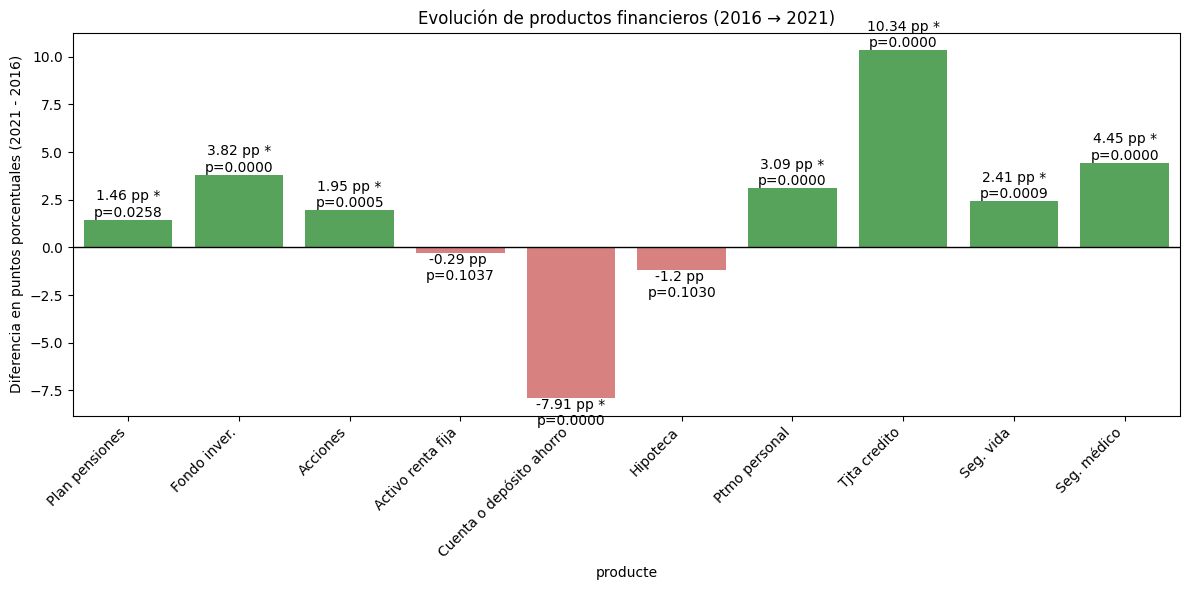

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

# Datos
df = taula_tendencia.copy()
df['p_value'] = df['p_value'].astype(float)
df['significativo'] = df['p_value'] < 0.05
df['tendencia'] = df['diff_pp'].apply(lambda x: 'Sube' if x > 0 else 'Baja')

plt.figure(figsize=(12,6))

# Paleta
palette = {'Sube': '#4CAF50', 'Baja': '#E57373'}

sns.barplot(
    data=df,
    x='producte',
    y='diff_pp',
    hue='tendencia',
    palette=palette,
    dodge=False
)

plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Diferencia en puntos porcentuales (2021 - 2016)')
plt.title('Evolución de productos financieros (2016 → 2021)')

# Etiquetas: diff_pp + p-value
for i, row in df.iterrows():
    marca = '*' if row['significativo'] else ''
    plt.text(
        i,
        row['diff_pp'],
        f"{row['diff_pp']} pp {marca}\np={row['p_value']:.4f}",
        ha='center',
        va='bottom' if row['diff_pp'] > 0 else 'top'
    )

plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()


# Ideas que nos indica Chi-quadrado:
  - Si p_value < 0.05 → el cambio és significativo --> hay evidencia estadística que la penetración ha cambiado. no es un cambio aleatorio, sino una tendencia real en la población.
  - Si p_value ≥ 0.05 → el canbio no és significativo --> No, posible cambio aleatorio.
## Observaciones:
  - Entre 2016 y 2021 se observan cambios significativos en la penetración de la mayoría de productos financieros. Destacan incrementos importantes en tarjetas de crédito (+10,3 pp), fondos de inversión (+3,8 pp) y seguros médicos (+4,4 pp).
  - También se detecta una caída significativa en cuentas o depósitos de ahorro (–7,9 pp).
  - En cambio, productos como la hipoteca y la renta fija no presentan cambios estadísticamente significativos.
## Productos comunes a Bank Atlas:  
  - Ptmo personal: incremento es de +3.1 puntos porcentuales;p‑value es extremadamente pequeño, por lo que el cambio es estadísticamente significativo. Es una tendencia real en la población.
  - Cuenta o depósito ahorro: resenta una caída muy significativa entre 2016 y 2021.La reducción es de –7.9 puntos porcentuales; y el p‑value es extremadamente pequeño:el descenso no es aleatorio, sino una tendencia real y estadísticamente sólida.
  - Hipoteca: entre 2016 y 2021 no muestra un cambio estadísticamente significativo.Se observa una ligera disminución de –1.2 puntos porcentuales, el p‑value es mayor que 0.05, lo que indica que esta variación puede deberse al azar y no refleja una tendencia real en la población.

# 1.1 Comparación nacional vs banco (Z‑test)

In [86]:
from statsmodels.stats.proportion import proportions_ztest

resultats_banc = []

comparacions = [
    ('Hipoteca', 'housing'),
    ('Ptmo personal', 'loan'),
    ('Cuenta o depósito ahorro', 'deposit')
]

for prod_nac, prod_banc in comparacions:
    
    # Proporciones
    p_nac = df_2021[prod_nac].mean()
    p_banc = df_bank[prod_banc].mean()
    
    # Conteos
    count = [df_2021[prod_nac].sum(), df_bank[prod_banc].sum()]
    nobs = [len(df_2021), len(df_bank)]
    
    # Test Z
    stat, p_value = proportions_ztest(count, nobs)
    
    resultats_banc.append({
        'producte': prod_nac,
        'pct_nacional_2021': round(p_nac*100, 2),
        'pct_banc': round(p_banc*100, 2),
        'diff_pp': round((p_banc - p_nac)*100, 2),
        'p_value': p_value
    })

taula_banc = pd.DataFrame(resultats_banc)
taula_banc['p_value'] = taula_banc['p_value'].apply(lambda x: format(x, '.15f'))
taula_banc


,producte,pct_nacional_2021,pct_banc,diff_pp,p_value
0,Hipoteca,30.47,47.31,16.84,0.000000000000000
1,Ptmo personal,20.62,13.08,-7.54,0.000000000000000
2,Cuenta o depósito ahorro,18.38,47.38,29.00,0.000000000000000


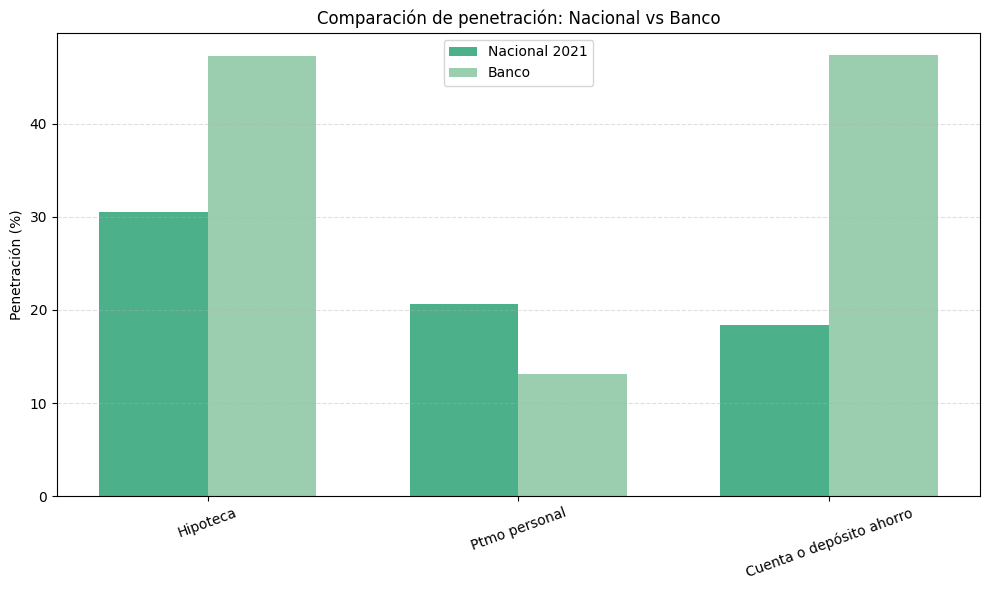

In [161]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
productos = taula_banc['producte']
nacional = taula_banc['pct_nacional_2021']
banco = taula_banc['pct_banc']

x = np.arange(len(productos))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, nacional, width, label='Nacional 2021', color="#4CB08A")
plt.bar(x + width/2, banco, width, label='Banco', color="#9ACEAE")

plt.xticks(x, productos, rotation=20)
plt.ylabel('Penetración (%)')
plt.title('Comparación de penetración: Nacional vs Banco')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("comparacion_banco_nacional.png", dpi=300, bbox_inches="tight")
plt.show()


## Observaciones:
- Hipoteca (housing):El banco tiene mucha más penetración hipotecaria que la media nacional (+16.8 pp).Esto indica que el banco está especialmente especializado o enfocado en hipotecas.
- Préstamo personal (loan):El banco tiene menos penetración que el mercado (–7.5 pp).Esto sugiere que el banco no es competitivo en préstamos personales o no los impulsa tanto.
- Cuenta o depósito ahorro (deposit):El banco tiene una penetración muchísimo mayor que la media (+29 pp).Esto es normal porque deposit en el dataset del banco significa “ha contratado un depósito en la campaña”, no “tiene una cuenta corriente”.

# 2. Comparación por grupo de edades (nacional vs banco)

#### Segmentación edades 2021

In [88]:
df_2021['age_group'] = (
    df_2021['Edad']
    .apply(lambda x: '18-30' if x <= 30 else
                     '31-40' if x <= 40 else
                     '41-50' if x <= 50 else
                     '51-65' if x <= 65 else
                     '>65')
)

In [89]:
eDADT_2021 = (df_2021['age_group'].value_counts().sort_index() / len(df_2021) * 100).round(2)
eDADT_2021


age_group
18-30    18.79
31-40    15.69
41-50    22.96
51-65    29.29
>65      13.27
Name: count, dtype: float64

#### Segmentación edades 2016

In [91]:
df_2016['age_group'] = (
    df_2016['Edad']
    .apply(lambda x: '18-30' if x <= 30 else
                     '31-40' if x <= 40 else
                     '41-50' if x <= 50 else
                     '51-65' if x <= 65 else
                     '>65')
)

In [92]:
eDADT_2016 = (df_2016['age_group'].value_counts().sort_index() / len(df_2016) * 100).round(2)
eDADT_2016

age_group
18-30    17.72
31-40    17.94
41-50    21.87
51-65    27.33
>65      15.13
Name: count, dtype: float64

#### Segmentación edades df_bank

In [93]:
df_bank['age_group'] = (
    df_bank['age']
    .apply(lambda x: '18-30' if x <= 30 else
                     '31-40' if x <= 40 else
                     '41-50' if x <= 50 else
                     '51-65' if x <= 65 else
                     '>65')
)


#### Agrupamos por valores que tenemos en común (Encuesta y Bank)

In [94]:
# para Encuesta 2021 último año
penetracion_edad_2021 = df_2021.groupby('age_group')[['Hipoteca','Ptmo personal','Cuenta o depósito ahorro']].mean() * 100


In [95]:
# para bank
penetracion_edad_banco = df_bank.groupby('age_group')[['housing','loan','deposit']].mean() * 100


In [96]:
# Renombramos columnas del banco para que coincidan en estructura
penetracion_edad_banco_ren = penetracion_edad_banco.rename(columns={
    'housing':'Hipoteca bK',
    'loan':'Ptmo personal bk',
    'deposit':'Cuenta o depósito ahorro bk'
})

# Convertimos los índices (age_group) en columnas para poder hacer merge
df_2021_age = penetracion_edad_2021.reset_index()
df_bank_age = penetracion_edad_banco_ren.reset_index()

# Merge por age_group
comparacion_edad = pd.merge(
    df_2021_age,
    df_bank_age,
    on='age_group',
    how='inner'
)

comparacion_edad = comparacion_edad.round(2)
comparacion_edad


,age_group,Hipoteca,Ptmo personal,Cuenta o depósito ahorro,Hipoteca bK,Ptmo personal bk,Cuenta o depósito ahorro bk
0,18-30,5.48,12.06,11.31,45.18,12.36,56.95
1,31-40,38.01,28.24,17.82,56.63,13.19,43.30
2,41-50,52.61,26.64,21.59,50.34,15.16,40.79
3,51-65,33.42,21.90,20.93,35.18,13.47,47.92
4,>65,12.14,10.49,17.86,4.27,0.50,80.40


In [97]:
comparacion_edad = comparacion_edad.rename(columns={
    'Hipoteca': 'Hipoteca_es',
    'Ptmo personal': 'Ptmo_es',
    'Cuenta o depósito ahorro': 'Deposito_es',
    'Hipoteca bK': 'Hipoteca_bk',
    'Ptmo personal bk': 'Ptmo_bk',
    'Cuenta o depósito ahorro bk': 'Deposito_bk'
})

comparacion_edad


,age_group,Hipoteca_es,Ptmo_es,Deposito_es,Hipoteca_bk,Ptmo_bk,Deposito_bk
0,18-30,5.48,12.06,11.31,45.18,12.36,56.95
1,31-40,38.01,28.24,17.82,56.63,13.19,43.30
2,41-50,52.61,26.64,21.59,50.34,15.16,40.79
3,51-65,33.42,21.90,20.93,35.18,13.47,47.92
4,>65,12.14,10.49,17.86,4.27,0.50,80.40


In [101]:
#diferencias entre encuesta y bank
dif_edad = comparacion_edad.copy()

# Diferències (banco - nacional)
dif_edad['Hipoteca_dif'] = dif_edad['Hipoteca_bk'] - dif_edad['Hipoteca_es']
dif_edad['Ptmo_dif'] = dif_edad['Ptmo_bk'] - dif_edad['Ptmo_es']
dif_edad['Deposito_dif'] = dif_edad['Deposito_bk'] - dif_edad['Deposito_es']

# Seleccionem només les diferències
dif_edad = dif_edad[['age_group','Hipoteca_dif','Ptmo_dif','Deposito_dif']]

dif_edad = dif_edad.round(2)
dif_edad


,age_group,Hipoteca_dif,Ptmo_dif,Deposito_dif
0,18-30,39.70,0.30,45.64
1,31-40,18.62,-15.05,25.48
2,41-50,-2.27,-11.48,19.20
3,51-65,1.76,-8.43,26.99
4,>65,-7.87,-9.99,62.54


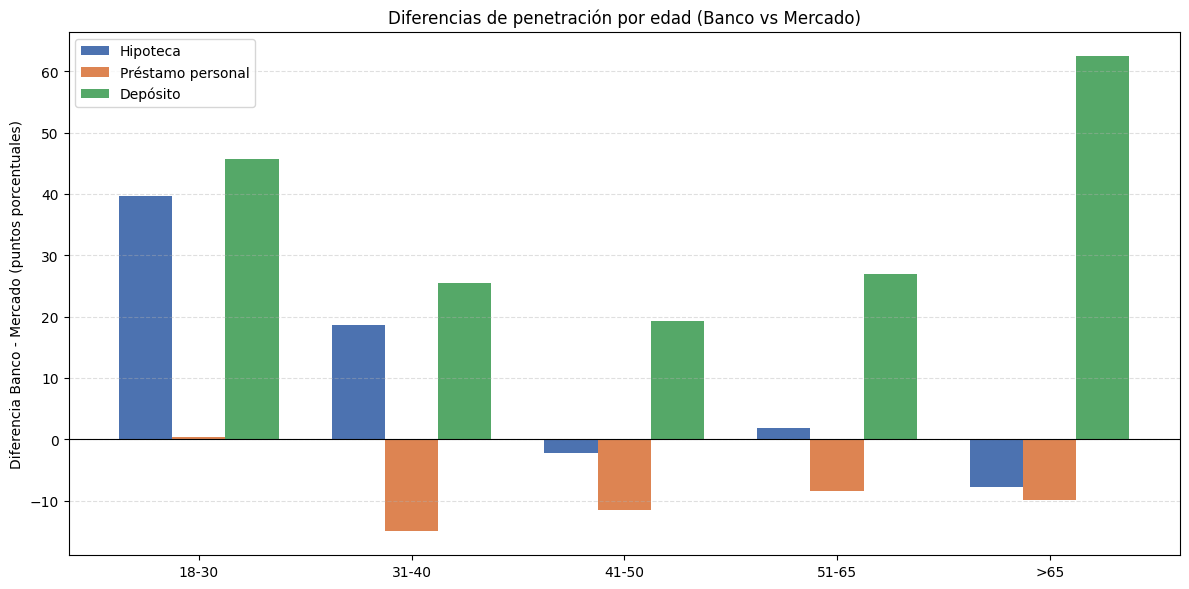

In [104]:
import matplotlib.pyplot as plt
import numpy as np

# Dades
age = dif_edad['age_group']
hip = dif_edad['Hipoteca_dif']
ptmo = dif_edad['Ptmo_dif']
dep = dif_edad['Deposito_dif']

x = np.arange(len(age))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, hip, width, label='Hipoteca', color='#4C72B0')
plt.bar(x, ptmo, width, label='Préstamo personal', color='#DD8452')
plt.bar(x + width, dep, width, label='Depósito', color='#55A868')

plt.xticks(x, age)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Diferencia Banco - Mercado (puntos porcentuales)')
plt.title('Diferencias de penetración por edad (Banco vs Mercado)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## Observaciones:
 - Valores positivos → el banco tiene más penetración que el mercado.

 - Valores negativos → el banco tiene menos penetración que el mercad 

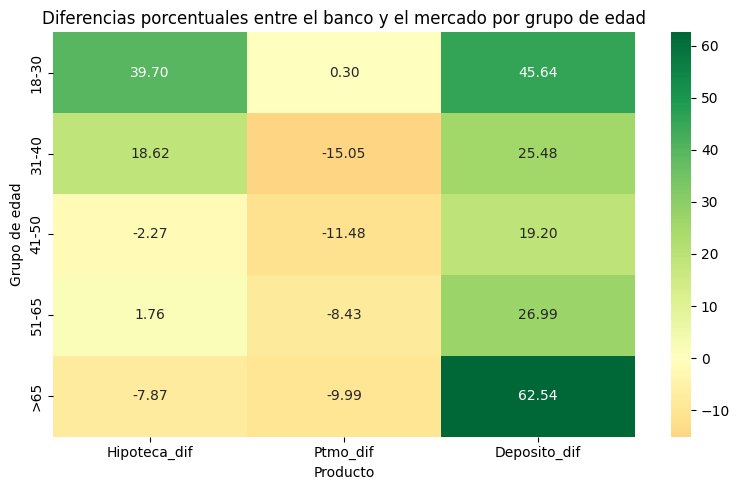

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt

# Preparem dades
heatmap_data = dif_edad.set_index('age_group')[['Hipoteca_dif','Ptmo_dif','Deposito_dif']]

plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', center=0, fmt='.2f')

plt.title('Diferencias porcentuales entre el banco y el mercado por grupo de edad')
plt.ylabel('Grupo de edad')
plt.xlabel('Producto')
plt.tight_layout()
plt.savefig("Diferencias_prcentuales_entre_banc_mercado.png", dpi=300, bbox_inches="tight")
plt.show()


## Conclusiones:
 - Hipotecas: El banco es fuerte en hipotecas entre 18–40 años, pero pierde fuerza en edades más avanzadas. 
     * El banco sobrecaptura claramente a los jóvenes (18–30) y a los adultos jóvenes (31–40).
     * A partir de los 41–50 años, el banco está alineado o ligeramente por debajo del mercado.
     * En mayores de 65 años, el banco presenta una penetración muy inferior.
 - Préstamo personal: El banco tiene una debilidad estructural en préstamos personales en todos los segmentos de edad.
     * El banco está por debajo del mercado en todas las edades, especialmente entre 31–65 años.
     * Solo en el grupo de 18–30 años está prácticamente alineado (+0.30 pp).
 - Depósito / Cuenta de ahorro:  El banco es muy fuerte en depósitos, especialmente entre jóvenes y sénior.
     * El banco tiene una penetración muy superior al mercado en todas las edades.
     * Especialmente elevada en 18–30 años (+45.64 pp) y en mayores de 65 (+62.54 pp).
     
El análisis por edades muestra que el banco está muy bien posicionado en hipotecas entre 18–40 años y en depósitos en todos los grupos de edad, pero presenta una debilidad clara en préstamos personales en todos los segmentos.
Estas diferencias indican que el banco debería adaptar su oferta de préstamos personales y reforzar la captación de hipotecas en edades más avanzadas, mientras aprovecha su fortaleza en depósitos para fidelizar tanto a jóvenes como a personas mayores.     

### Conclusiones totales:
 - Los test estadísticos muestran que, entre 2016 y 2021, las tendencias nacionales se desplazan hacia productos de inversión, seguros y préstamos personales, mientras caen los depósitos tradicionales. 
 - Al comparar con el banco, las pruebas Z evidencian que este mantiene una penetración muy superior en depósitos y en hipotecas jóvenes, pero significativamente inferior en préstamos personales y en hipotecas de mayor edad. 
 - La segmentación confirma un posicionamiento desequilibrado respecto al mercado.

- Por tanto, sí es necesario adaptar la oferta actual y desarrollar nuevos productos, especialmente en préstamos personales e inversión, para alinearse con las tendencias nacionales y mejorar la competitividad del banco.

### ¿Cómo variamos según el nivel educativo?

### Data Loading, Cleaning & Product Adoption Comparison

In this section, we load and merge National Bank demographic and product datasets for 2016 and 2021.  
We clean product variables by converting Sí/No responses into numeric values and calculate product adoption percentages by education level.

We also load the Bank Marketing dataset, standardize its education categories, and compute the same adoption metrics (loan, housing, deposit).

Finally, we generate bar charts comparing product adoption across:
- National Bank 2016
- National Bank 2021
- Bank Marketing 2016

                    loan     housing    deposit
edu_level                                      
-97             0.000000  100.000000   0.000000
-99             0.000000    0.000000   0.000000
Primaria       16.574731   25.479380  18.754925
Secundaria     19.147844   31.160164  25.256674
Universitaria  17.733286   40.436182  37.289954
                    loan    housing    deposit
edu_level                                     
Primaria       20.930233  24.689922  11.395349
Secundaria     21.118012  25.828157  15.890269
Universitaria  20.079951  37.822878  25.399754
                    loan    housing    deposit
education                                     
Primaria       13.666667  49.466667  39.400000
Secundaria     15.824055  53.312648  44.734441
Universitaria   9.818280  39.164632  54.109032
Unknown         5.241935  35.080645  50.806452


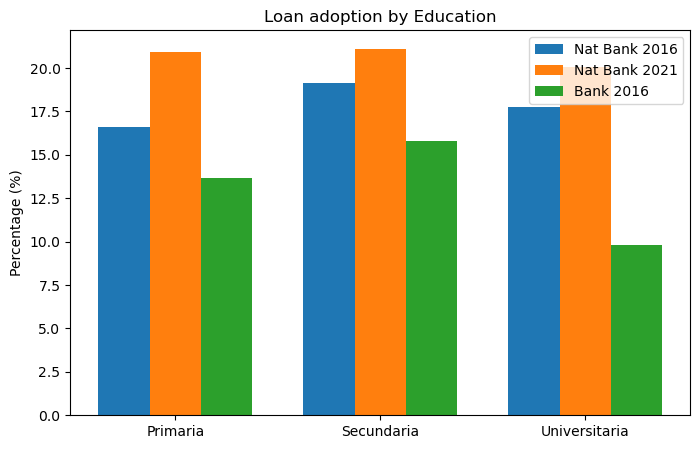

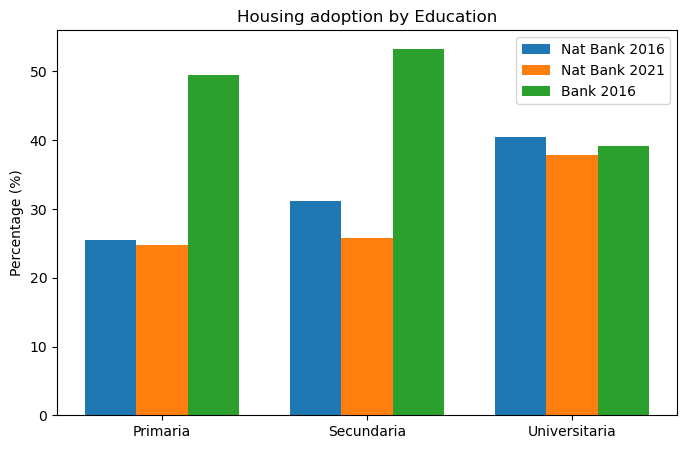

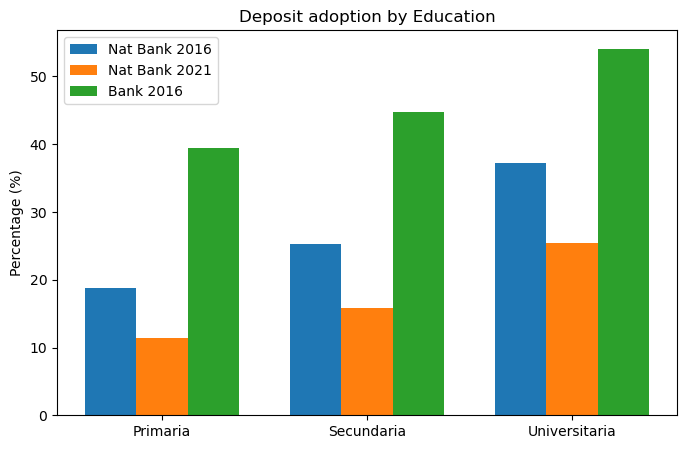

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load National Bank datasets
# -------------------------------
dem_16 = pd.read_csv(r"C:\Personal\Susi\ITACADEMY\ProjecteData\Equip_23\Data\23 March\01_Demografia_cleaning_16.csv", encoding='utf-8')
prod_16 = pd.read_csv(r"C:\Personal\Susi\ITACADEMY\ProjecteData\Equip_23\Data\23 March\02_Product_Activos_cleaning_16.csv", encoding='utf-8')

dem_21 = pd.read_csv(r"C:\Personal\Susi\ITACADEMY\ProjecteData\Equip_23\Data\23 March\01_Demografia_cleaning_21.csv", encoding='utf-8')
prod_21 = pd.read_csv(r"C:\Personal\Susi\ITACADEMY\ProjecteData\Equip_23\Data\23 March\02_Product_Activos_cleaning_21.csv", encoding='utf-8')

# -------------------------------
# 2. Merge National Bank demographic + products
# -------------------------------
df_16 = pd.merge(dem_16.reset_index(), prod_16.reset_index(), on='index')
df_21 = pd.merge(dem_21.reset_index(), prod_21.reset_index(), on='index')

# -------------------------------
# 3. Convert Sí/No to 1/0
# -------------------------------
def convert_yes_no(df):
    cols = ['Plan pensiones','Fondo inver.','Acciones','Activo renta fija',
            'Cuenta o depósito ahorro','Hipoteca','Ptmo personal','Tjta credito',
            'Seg. vida','Seg. médico']
    for col in cols:
        df[col] = df[col].replace({'Sí':1, 'Si':1, 'No':0, 'N/A':0, 'missing':0})
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    return df

df_16 = convert_yes_no(df_16)
df_21 = convert_yes_no(df_21)

# -------------------------------
# 4. Segment by education (select products analogous to bank)
# -------------------------------
nat_prod_map = {'loan':'Ptmo personal', 'housing':'Hipoteca', 'deposit':'Cuenta o depósito ahorro'}

def segment_national(df):
    summary = df.groupby('edu_level')[[v for v in nat_prod_map.values()]].mean() * 100
    summary = summary.rename(columns={v:k for k,v in nat_prod_map.items()})
    return summary

nat_2016 = segment_national(df_16)
nat_2021 = segment_national(df_21)
print(nat_2016)
print(nat_2021)

# Keep only relevant education levels
common_levels = ['Primaria','Secundaria','Universitaria']
nat_2016_plot = nat_2016.loc[common_levels]
nat_2021_plot = nat_2021.loc[common_levels]

# -------------------------------
# 5. Load Bank dataset and clean
# -------------------------------
df_bank = pd.read_csv(r"C:\Personal\Susi\ITACADEMY\ProjecteData\Equip_23\Data\16 March\Bank_Marketing_Cleaned_16_march.csv")
df_bank.columns = df_bank.columns.str.strip().str.lower()

# Convert yes/no to 1/0
for col in ['loan','housing','deposit']:
    df_bank[col] = df_bank[col].astype(str).str.strip().str.lower().map({'yes':1,'no':0}).fillna(0)

# Map education to match National Bank
edu_map = {'primary':'Primaria','secondary':'Secundaria','tertiary':'Universitaria','unknown':'Unknown'}
df_bank['education'] = df_bank['education'].astype(str).str.strip().str.lower().map(edu_map)

bank_segment = df_bank.groupby('education')[['loan','housing','deposit']].mean() * 100
print(bank_segment)
bank_plot = bank_segment.loc[common_levels]  # keep only common levels

# -------------------------------
# 6. Plot comparison
# -------------------------------
x = np.arange(len(common_levels))
width = 0.25

for prod in ['loan','housing','deposit']:
    plt.figure(figsize=(8,5))
    plt.bar(x - width, nat_2016_plot[prod], width=width, label='Nat Bank 2016')
    plt.bar(x, nat_2021_plot[prod], width=width, label='Nat Bank 2021')
    plt.bar(x + width, bank_plot[prod], width=width, label='Bank 2016')
    
    plt.xticks(x, common_levels)
    plt.ylabel('Percentage (%)')
    plt.title(f'{prod.capitalize()} adoption by Education')
    plt.legend()
    plt.show()

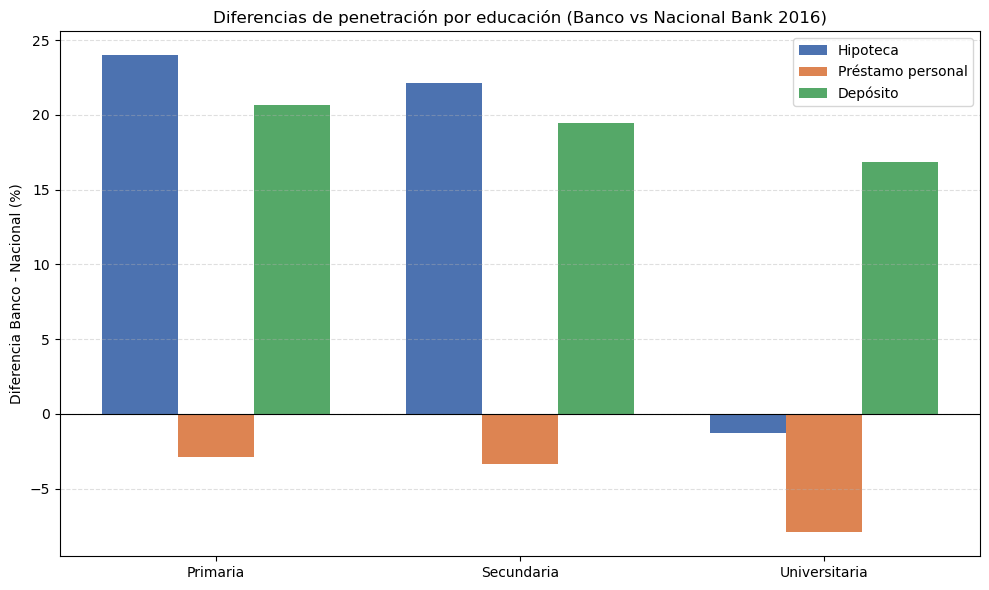

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load National Bank datasets
# -------------------------------
dem_16 = pd.read_csv(r"C:\Personal\Susi\ITACADEMY\ProjecteData\Equip_23\Data\23 March\01_Demografia_cleaning_16.csv", encoding='utf-8')
prod_16 = pd.read_csv(r"C:\Personal\Susi\ITACADEMY\ProjecteData\Equip_23\Data\23 March\02_Product_Activos_cleaning_16.csv", encoding='utf-8')

dem_21 = pd.read_csv(r"C:\Personal\Susi\ITACADEMY\ProjecteData\Equip_23\Data\23 March\01_Demografia_cleaning_21.csv", encoding='utf-8')
prod_21 = pd.read_csv(r"C:\Personal\Susi\ITACADEMY\ProjecteData\Equip_23\Data\23 March\02_Product_Activos_cleaning_21.csv", encoding='utf-8')

# -------------------------------
# 2. Merge National Bank demographic + products
# -------------------------------
df_16 = pd.merge(dem_16.reset_index(), prod_16.reset_index(), on='index')
df_21 = pd.merge(dem_21.reset_index(), prod_21.reset_index(), on='index')

# -------------------------------
# 3. Convert Sí/No to 1/0
# -------------------------------
def convert_yes_no(df):
    cols = ['Plan pensiones','Fondo inver.','Acciones','Activo renta fija',
            'Cuenta o depósito ahorro','Hipoteca','Ptmo personal','Tjta credito',
            'Seg. vida','Seg. médico']
    for col in cols:
        df[col] = df[col].replace({'Sí':1, 'Si':1, 'No':0, 'N/A':0, 'missing':0})
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    return df

df_16 = convert_yes_no(df_16)
df_21 = convert_yes_no(df_21)

# -------------------------------
# 4. Segment by education (select products analogous to bank)
# -------------------------------
nat_prod_map = {'loan':'Ptmo personal', 'housing':'Hipoteca', 'deposit':'Cuenta o depósito ahorro'}

def segment_national(df):
    summary = df.groupby('edu_level')[[v for v in nat_prod_map.values()]].mean() * 100
    summary = summary.rename(columns={v:k for k,v in nat_prod_map.items()})
    return summary

nat_2016 = segment_national(df_16)
nat_2021 = segment_national(df_21)

# Keep only relevant education levels
common_levels = ['Primaria','Secundaria','Universitaria']
nat_2016_plot = nat_2016.loc[common_levels]
nat_2021_plot = nat_2021.loc[common_levels]

# -------------------------------
# 5. Load Bank dataset and clean
# -------------------------------
df_bank = pd.read_csv(r"C:\Personal\Susi\ITACADEMY\ProjecteData\Equip_23\Data\16 March\Bank_Marketing_Cleaned_16_march.csv")
df_bank.columns = df_bank.columns.str.strip().str.lower()

# Convert yes/no to 1/0
for col in ['loan','housing','deposit']:
    df_bank[col] = df_bank[col].astype(str).str.strip().str.lower().map({'yes':1,'no':0}).fillna(0)

# Map education to match National Bank
edu_map = {'primary':'Primaria','secondary':'Secundaria','tertiary':'Universitaria','unknown':'Unknown'}
df_bank['education'] = df_bank['education'].astype(str).str.strip().str.lower().map(edu_map)

bank_segment = df_bank.groupby('education')[['loan','housing','deposit']].mean() * 100
bank_plot = bank_segment.loc[common_levels]  # keep only common levels

# -------------------------------
# 6. Compute differences for plotting (Bank - Nat Bank)
# -------------------------------
dif_edu = pd.DataFrame({
    'edu_level': common_levels,
    'Hipoteca_dif': bank_plot['housing'].values - nat_2016_plot['housing'].values,
    'Ptmo_dif': bank_plot['loan'].values - nat_2016_plot['loan'].values,
    'Deposito_dif': bank_plot['deposit'].values - nat_2016_plot['deposit'].values
})

dif_edu = dif_edu.round(2)
#dif_edu.to_csv(r"C:\Personal\Susi\Bank Simulator\Output\dif_educacion.csv", index=False)

# -------------------------------
# 7. Plot differences by education
# -------------------------------
x = np.arange(len(common_levels))
width = 0.25

hip = dif_edu['Hipoteca_dif']
ptmo = dif_edu['Ptmo_dif']
dep = dif_edu['Deposito_dif']

plt.figure(figsize=(10,6))
plt.bar(x - width, hip, width, label='Hipoteca', color='#4C72B0')
plt.bar(x, ptmo, width, label='Préstamo personal', color='#DD8452')
plt.bar(x + width, dep, width, label='Depósito', color='#55A868')

plt.xticks(x, common_levels)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Diferencia Banco - Nacional (%)')
plt.title('Diferencias de penetración por educación (Banco vs Nacional Bank 2016)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Conclusiones (Resumen)

- **Hipotecas:** El banco tiene alta penetración en clientes con primaria y secundaria, pero pierde ventaja en el segmento universitario.
- **Préstamos personales:** Es el producto más débil del banco, quedando por debajo del mercado en todos los niveles educativos, especialmente en universitarios.
- **Depósitos / Ahorro:** Es el punto más fuerte del banco, con penetración superior al mercado en todos los niveles educativos.

**Conclusión general:**  
El banco muestra un posicionamiento sólido en productos tradicionales (depósitos e hipotecas en niveles educativos bajos), pero presenta debilidad en préstamos personales y menor competitividad en clientes universitarios. Se recomienda reforzar la oferta de préstamos personales y mejorar la propuesta hipotecaria para segmentos más formados.

### ¿Cómo cambia el riesgo financiero según el nivel educativo?

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Paleta visual coherente ─────────────────────────────────────────────────
C16    = "#1D4ED8"   # azul  — EFF 2016
C21    = "#DC2626"   # rojo  — EFF 2021
CBANK  = "#059669"   # verde — Bank Marketing
CGAP   = "#F59E0B"   # ámbar — brecha / gap
CBKG   = "#F8FAFC"   # fondo suave

plt.rcParams.update({
    "figure.facecolor": CBKG,
    "axes.facecolor":   CBKG,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "figure.dpi":       130,
    "font.size":        10
})

# ── Rutas — ajusta a tu entorno ─────────────────────────────────────────────
BASE_EFF  = r"C:\Personal\Susi\ITACADEMY\ProjecteData\Equip_23\Data\23 March\\"
BASE_BANK = r"C:\Personal\Susi\ITACADEMY\ProjecteData\Equip_23\Data\16 March\\"

# EFF datasets
df_dem16  = pd.read_csv(BASE_EFF + "01_Demografia_cleaning_16.csv",  sep=",", encoding="latin1")
df_dem21  = pd.read_csv(BASE_EFF + "01_Demografia_cleaning_21.csv",  sep=",", encoding="latin1")
df_prod16 = pd.read_csv(BASE_EFF + "02_Product_Activos_cleaning_16.csv", sep=",", encoding="latin1")
df_prod21 = pd.read_csv(BASE_EFF + "02_Product_Activos_cleaning_21.csv", sep=",", encoding="latin1")
df_fin16  = pd.read_csv(BASE_EFF + "04_Conocimientos_Financieros_2016_GEN_Cleaned.csv", sep=",", encoding="latin1")
df_fin21  = pd.read_csv(BASE_EFF + "04_Conocimientos_Financieros_2021_GEN_Cleaned.csv", sep=",", encoding="latin1")
df_ges16  = pd.read_csv(BASE_EFF + "09_Gestion_Gastos_y_Deudas_2016_GEN_Cleaned.csv",  sep=",", encoding="latin1")
df_ges21  = pd.read_csv(BASE_EFF + "09_Gestion_Gastos_y_Deudas_2021_GEN_Cleaned.csv",  sep=",", encoding="latin1")

# Bank Marketing dataset
df_bank   = pd.read_csv(BASE_BANK + "Bank_Marketing_Cleaned_16_march.csv", sep=",", encoding="latin1")

print("Registros EFF 2016 (demografía):", len(df_dem16))
print("Registros EFF 2021 (demografía):", len(df_dem21))
print("Registros Bank Marketing:        ", len(df_bank))

Registros EFF 2016 (demografía): 8554
Registros EFF 2021 (demografía): 7764
Registros Bank Marketing:         11162


### Preparación del Dataset EFF (2016–2021)

Se convierten respuestas Sí/No a valores numéricos y se crean indicadores de productos financieros (inversión, crédito, protección).  
También se generan variables de gestión financiera como ahorro total, uso de crédito, riesgo, resiliencia y un score financiero combinado.

Finalmente, se unen los datos de 2016 y 2021, se añade la columna de año y se crean grupos de edad para el análisis.

In [12]:
import pandas as pd
import numpy as np

# Convert Yes/No to numbers
SI_NO = {"Sí": 1, "No": 0, "SÃ­": 1}

# --- PRODUCTS ---
def prep_products(df):
    df = df.replace(SI_NO)

    cols_inv = ["Fondo inver.", "Acciones", "Plan pensiones"]
    cols_cred = ["Hipoteca", "Ptmo personal", "Tjta credito"]
    cols_prot = ["Seg. vida", "Seg. mÃ©dico"]

    df["prod_inversion"] = df[cols_inv].apply(pd.to_numeric, errors="coerce").sum(axis=1)
    df["prod_credito"] = df[cols_cred].apply(pd.to_numeric, errors="coerce").sum(axis=1)
    df["prod_proteccion"] = df[cols_prot].apply(pd.to_numeric, errors="coerce").sum(axis=1)

    return df[["prod_inversion", "prod_credito", "prod_proteccion"]]


# --- FINANCIAL MANAGEMENT ---
def build_gestion(df):
    df = df.replace(SI_NO)

    ahorro = df[["AhorroEfectivo", "AhorroCuentaCorriente", "AhorroPlazoFijo"]].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)
    credito = df[["UsoTarjetaCredito", "UsoLineaCredito", "PrestamoPersonal"]].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)
    riesgo = df[["PagosRetrasados", "Impagos"]].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)

    resiliencia = pd.to_numeric(df["MesesCubiertosGastos"], errors="coerce")
    uso_ahorros = pd.to_numeric(df["UsoAhorros"], errors="coerce").fillna(0)

    score = ahorro + resiliencia.fillna(0) - credito - riesgo - uso_ahorros

    return pd.DataFrame({
        "ahorro_total": ahorro,
        "uso_credito": credito,
        "riesgo_financiero": riesgo,
        "resiliencia": resiliencia,
        "uso_ahorros": uso_ahorros,
        "score_financiero": score
    })


# --- APPLY TO DATA ---
prod16 = prep_products(df_prod16)
prod21 = prep_products(df_prod21)

gest16 = build_gestion(df_ges16)
gest21 = build_gestion(df_ges21)

# --- FINAL DATASET ---
eff16 = pd.concat([df_dem16, prod16, gest16], axis=1)
eff16["year"] = 2016

eff21 = pd.concat([df_dem21, prod21, gest21], axis=1)
eff21["year"] = 2021

eff = pd.concat([eff16, eff21])

# Age groups
eff["grupo_edad"] = pd.cut(
    eff["Edad"],
    bins=[17, 30, 45, 65, 100],
    labels=["Joven", "Adulto", "Medio", "Mayor"]
)

print(eff.shape)
eff.head()

(16318, 22)


,AÃ±o_entrev.,Mes_entrev.,AÃ±o_naci.,Edad,labor_status,familia,edu_level,CCAA,ocupacion,trabajo_rel.,...,prod_credito,prod_proteccion,ahorro_total,uso_credito,riesgo_financiero,resiliencia,uso_ahorros,score_financiero,year,grupo_edad
0,2016,12,1998,18,otros inactivos,No vive con pareja pero vive con otros adultos,Secundaria,Andalusia,No aplicable,NaN,...,0.0,0.0,1.0,0.0,0.0,7.0,0.0,8.0,2016,Joven
1,2016,10,1982,33,missing,Vive con pareja,Universitaria,Andalusia,Otros administrativos,Si,...,3.0,1.0,0.0,0.0,0.0,2.0,0.0,2.0,2016,Adulto
2,2016,10,1967,49,otros inactivos,Vive con pareja,Primaria,Andalusia,Silvicultura,No,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,3.0,2016,Medio
3,2016,10,1962,54,otros inactivos,Vive con pareja,Primaria,Andalusia,Peones agrÃ­colas,No,...,0.0,0.0,0.0,0.0,0.0,5.0,0.0,5.0,2016,Medio
4,2016,10,1952,64,jubilado,Vive con pareja,Primaria,Andalusia,AlimentaciÃ³n,No,...,1.0,0.0,0.0,0.0,0.0,5.0,0.0,5.0,2016,Medio


In [14]:
import pandas as pd

# --- CLEAN COLUMN NAMES ---
df_bank.columns = df_bank.columns.str.strip().str.lower()

# --- AGE GROUPS ---
df_bank["grupo_edad"] = pd.cut(
    df_bank["age"],
    bins=[17, 30, 45, 65, 100],
    labels=["Joven", "Adulto", "Medio", "Mayor"]
)

# --- CONVERT "deposit" TO 0/1 ---
df_bank["deposito_bin"] = (df_bank["deposit"] == "yes").astype(int)

# --- CONVERSION RATES ---
conv_edad = df_bank.groupby("grupo_edad")["deposito_bin"].mean()
conv_job = df_bank.groupby("job")["deposito_bin"].mean().sort_values(ascending=False)
conv_edu = df_bank.groupby("education")["deposito_bin"].mean()
conv_month = df_bank.groupby("month")["deposito_bin"].mean()

# --- AVERAGE BALANCE ---
balance_edad = df_bank.groupby("grupo_edad")["balance"].mean()

# --- RESULT ---
print("Tasa global de depósito:", round(df_bank["deposito_bin"].mean() * 100, 1), "%")

Tasa global de depósito: 47.4 %


In [16]:
from scipy import stats
import pandas as pd

KPIS = ["prod_inversion","prod_credito","prod_proteccion",
        "ahorro_total","uso_credito","riesgo_financiero",
        "resiliencia","score_financiero"]

results = []

for col in KPIS:
    # Split data by year
    data_2016 = eff[eff["year"] == 2016][col].dropna()
    data_2021 = eff[eff["year"] == 2021][col].dropna()

    # Means
    mean_2016 = data_2016.mean()
    mean_2021 = data_2021.mean()

    # Difference
    diff = mean_2021 - mean_2016
    pct = (diff / (mean_2016 + 1e-9)) * 100

    # Statistical test
    _, p = stats.ttest_ind(data_2016, data_2021)

    # Significance level
    if p < 0.001:
        sig = "***"
    elif p < 0.01:
        sig = "**"
    elif p < 0.05:
        sig = "*"
    else:
        sig = "ns"

    # Save results
    results.append({
        "Indicador": col,
        "Media 2016": round(mean_2016, 3),
        "Media 2021": round(mean_2021, 3),
        "Δ Abs": round(diff, 3),
        "Δ %": round(pct, 1),
        "Significancia": sig
    })

# Final table
df_summary = pd.DataFrame(results).set_index("Indicador")

print("★★★ p<0.001  ★★ p<0.01  ★ p<0.05  ns = no significativo\n")
print(df_summary)

★★★ p<0.001  ★★ p<0.01  ★ p<0.05  ns = no significativo

                   Media 2016  Media 2021  Δ Abs   Δ % Significancia
Indicador                                                           
prod_inversion          0.445       0.517  0.072  16.3           ***
prod_credito            1.051       1.173  0.122  11.6           ***
prod_proteccion         0.492       0.560  0.069  13.9           ***
ahorro_total            0.725       0.884  0.159  21.9           ***
uso_credito             0.051       0.049 -0.002  -4.4            ns
riesgo_financiero       0.076       0.054 -0.023 -29.6           ***
resiliencia             4.869       5.200  0.331   6.8           ***
score_financiero        5.165       5.737  0.572  11.1           ***


### Comparación de Riesgo Financiero entre España (EFF 2016) y el Banco

En esta sección se calcula y compara el **riesgo financiero promedio** por nivel educativo entre:
- La encuesta EFF España 2016  
- El dataset del Banco (2016)

Se construye un indicador comparable sumando el uso de productos (loan, housing, deposit), se agrupan los datos por nivel educativo y se genera un DataFrame con las diferencias entre ambos. Finalmente, se visualiza la comparación mediante un gráfico de barras.

               Riesgo España 2016  Riesgo Bank 2016  \
Primaria                     0.11              1.03   
Secundaria                   0.07              1.14   
Universitaria                0.03              1.03   

               Diferencia (Bank - España)  
Primaria                             0.91  
Secundaria                           1.06  
Universitaria                        1.00  


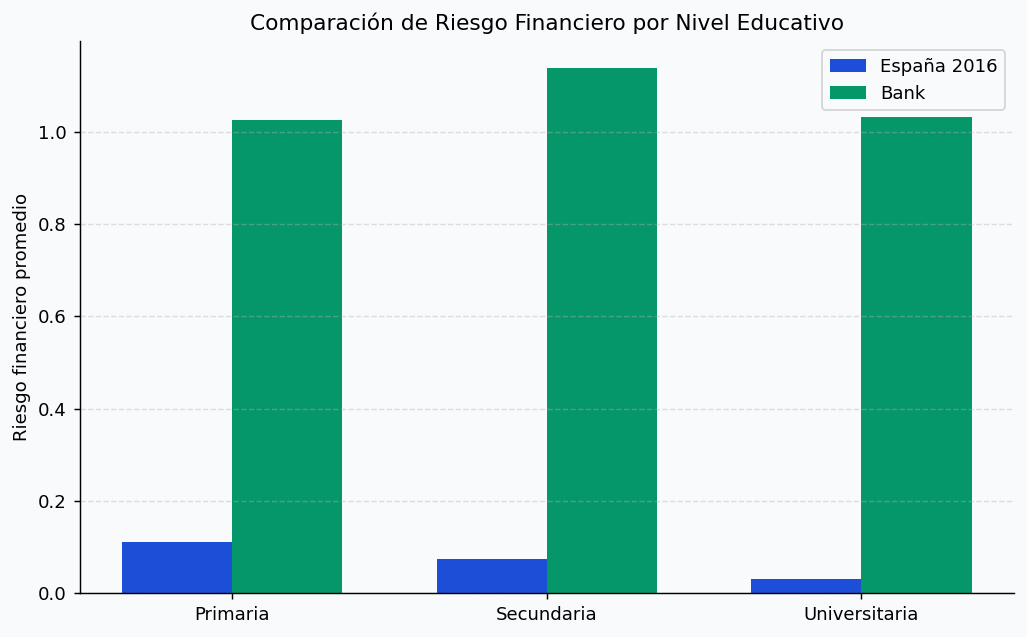

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Prepare Bank dataset with riesgo_financiero
# -------------------------------
# First, we need to calculate an equivalent riesgo_financiero in Bank Marketing
# We'll assume "uso_credito" = usage of loans (loan + housing + deposit), similar to EFF

# Convert loan/housing/deposit to numeric 0/1
for col in ['loan','housing','deposit']:
    df_bank[col] = df_bank[col].astype(str).str.strip().str.lower().map({'yes':1,'no':0}).fillna(0)

# Compute "riesgo_financiero" as total credit exposure
df_bank['riesgo_financiero'] = df_bank[['loan','housing','deposit']].sum(axis=1)

# Map education
edu_map = {'primary':'Primaria','secondary':'Secundaria','tertiary':'Universitaria','unknown':'Unknown'}
df_bank['education'] = df_bank['education'].astype(str).str.strip().str.lower().map(edu_map)

# Group by education and compute mean riesgo
bank_riesgo = df_bank.groupby('education')['riesgo_financiero'].mean()

# -------------------------------
# 2. Prepare EFF survey riesgo_financiero
# -------------------------------
# Already computed in eff16 and eff21
# We'll take 2016 for comparison with bank
eff16_riesgo = eff16.groupby('edu_level')['riesgo_financiero'].mean()

# Keep only common levels
common_levels = ['Primaria','Secundaria','Universitaria']
bank_riesgo_plot = bank_riesgo.loc[common_levels]
eff16_riesgo_plot = eff16_riesgo.loc[common_levels]

# -------------------------------
# 3. Combine into a comparison DataFrame
# -------------------------------
df_riesgo_comp = pd.DataFrame({
    'Riesgo España 2016': eff16_riesgo_plot,
    'Riesgo Bank 2016': bank_riesgo_plot
})
df_riesgo_comp['Diferencia (Bank - España)'] = df_riesgo_comp['Riesgo Bank 2016'] - df_riesgo_comp['Riesgo España 2016']
df_riesgo_comp = df_riesgo_comp.round(2)
df_riesgo_comp.to_csv(r"C:\Personal\Susi\Bank Simulator\Output\riesgo_comparacion.csv", index=True)
print(df_riesgo_comp)

# -------------------------------
# 4. Plot comparison
# -------------------------------
x = np.arange(len(common_levels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, eff16_riesgo_plot, width, label='España 2016', color='#1D4ED8')
plt.bar(x + width/2, bank_riesgo_plot, width, label='Bank', color='#059669')

plt.xticks(x, common_levels)
plt.ylabel('Riesgo financiero promedio')
plt.title('Comparación de Riesgo Financiero por Nivel Educativo')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Conclusion
El banco muestra un riesgo financiero muy superior al mercado en todos los niveles educativos (+0.9 a +1.06 pp). Esto señala una cartera más expuesta al crédito y más endeudada que la población española, sin diferencias relevantes por nivel educativo. El gap es estructural y refleja un perfil de cliente del banco altamente bancarizado y con mayor uso de préstamos.

